Лабораторная работа №3

№1. Геометрия данных в пространстве признаков.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler
# Загрузка данных
df = pd.read_csv('../data/data_set1.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 10299 строк, 88 столбцов


,subject,activities,tBodyAccmeanX,tBodyAccmeanY,tBodyAccmeanZ,tBodyAccstdX,tBodyAccstdY,tBodyAccstdZ,tGravityAccmeanX,tGravityAccmeanY,...,fBodyBodyGyroJerkMagmean,fBodyBodyGyroJerkMagstd,fBodyBodyGyroJerkMagmeanFreq,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,2,STANDING,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,0.936489,-0.282719,...,-0.890165,-0.907308,0.071645,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,2,STANDING,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,0.927404,-0.289215,...,-0.951977,-0.938212,-0.401189,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,2,STANDING,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,0.929915,-0.287513,...,-0.985689,-0.983273,0.062891,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,2,STANDING,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,0.928881,-0.293396,...,-0.985562,-0.985843,0.116695,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,2,STANDING,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,0.926600,-0.302961,...,-0.990498,-0.990572,-0.121711,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857


In [42]:
# Убираем служебные столбцы (subject и Activity)
X = df.drop(['subject', 'activities'], axis=1)
y = df['activities']
print("\n1.1 Анализ структуры данных")
print(f"Число объектов (наблюдений): {X.shape[0]}")
print(f"Число признаков: {X.shape[1]}")
df.shape[1]


1.1 Анализ структуры данных
Число объектов (наблюдений): 10299
Число признаков: 86


88

№1.2

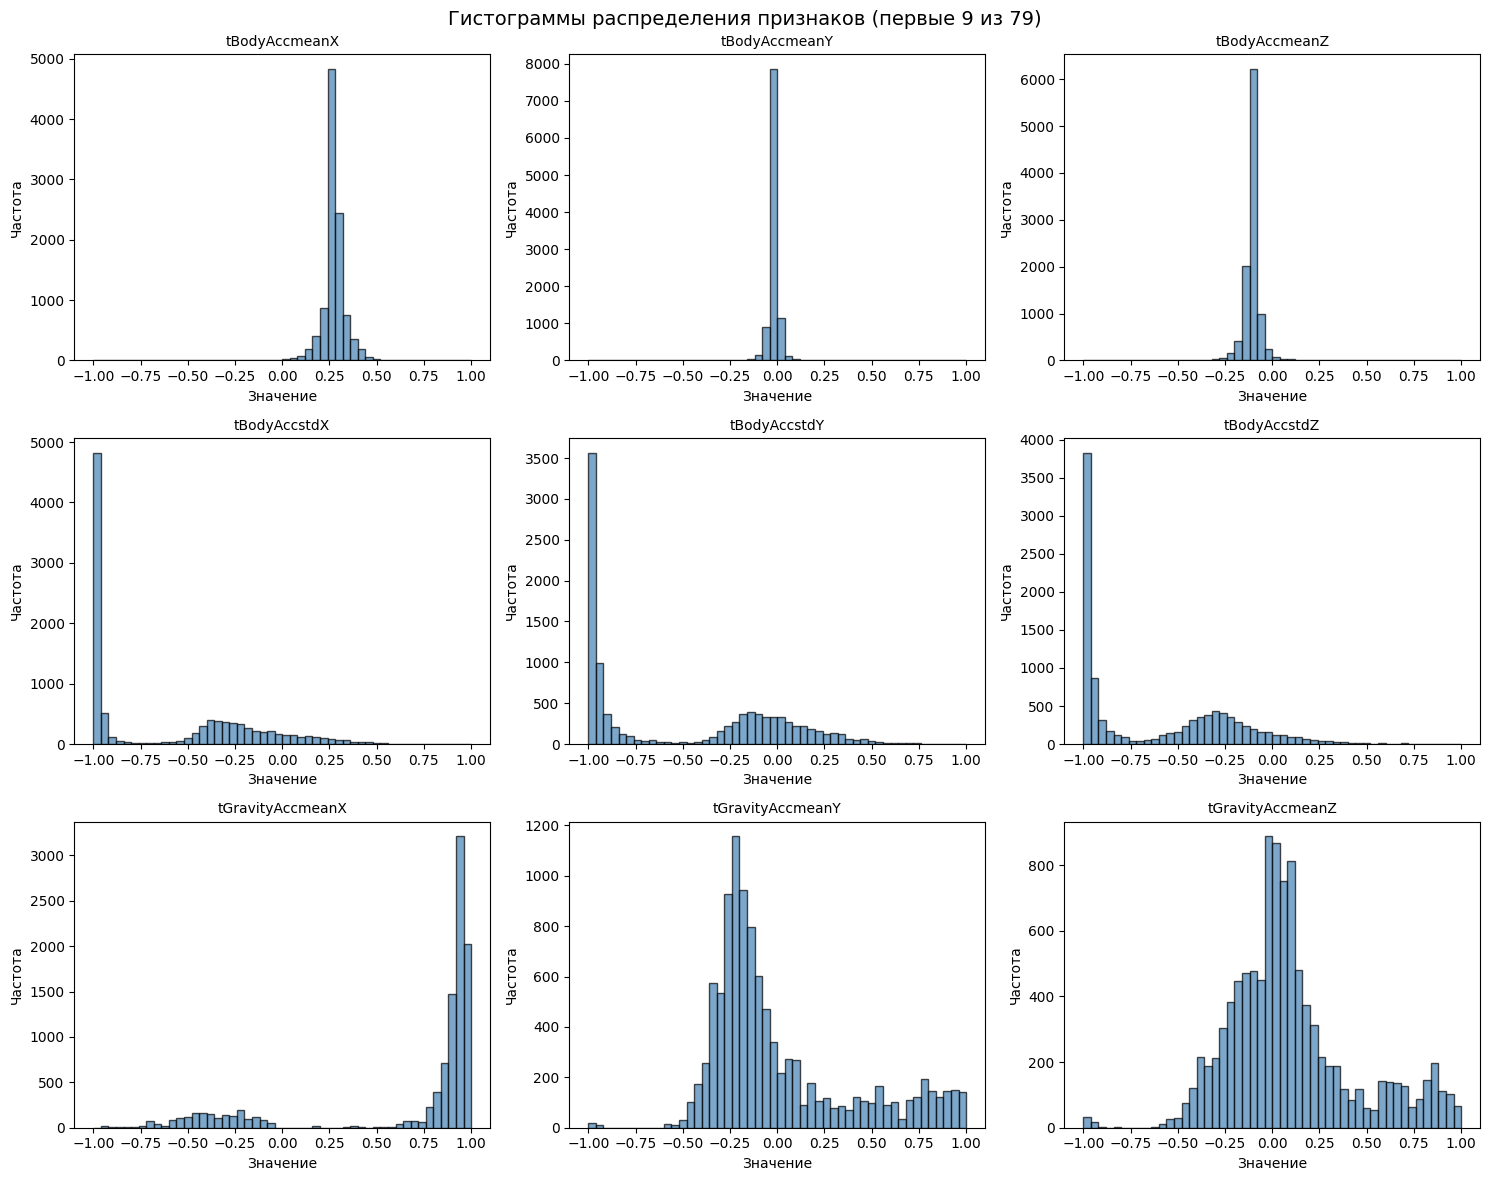

'По горизонтали — возможные значения признака, по вертикали — количество объектов с таким значением.\nГистограммы показывают, что большинство признаков имеют распределение, близкое к нормальному.\nНекоторые признаки имеют асимметрию (скошены влево или вправо).\n'

In [26]:
# Выбираем первые 9 признаков из 79
first_features = X.columns[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(first_features):
    axes[i].hist(X[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Гистограммы распределения признаков (первые 9 из 79)', fontsize=14)
plt.tight_layout()
plt.show()

# Статистическое описание распределений
'''print("\n2. Статистическое описание признаков")
print(X[first_features].describe().round(3))'''
'''По горизонтали — возможные значения признака, по вертикали — количество объектов с таким значением.
Гистограммы показывают, что большинство признаков имеют распределение, близкое к нормальному.
Некоторые признаки имеют асимметрию (скошены влево или вправо).
'''

Матрица корреляций — это таблица, где на пересечении строки i и столбца j стоит число, показывающее силу линейной связи между i-м и j-м признаками.
Коэффициент корреляции Пирсона (r) принимает значения от -1 до 1:
r = 1	Полная положительная связь: когда один признак растет, второй тоже растет строго пропорционально
r = -1	Полная отрицательная связь: когда один признак растет, второй убывает строго пропорционально
r = 0	Нет линейной связи: признаки независимы (но может быть нелинейная связь)
|r| > 0.7	Сильная корреляция — признаки содержат избыточную информацию
|r| < 0.3	Слабая корреляция — признаки несут разную информацию
Если два признака сильно коррелируют, они несут почти одинаковую информацию. Это обосновывает применение PCA для сжатия данных.

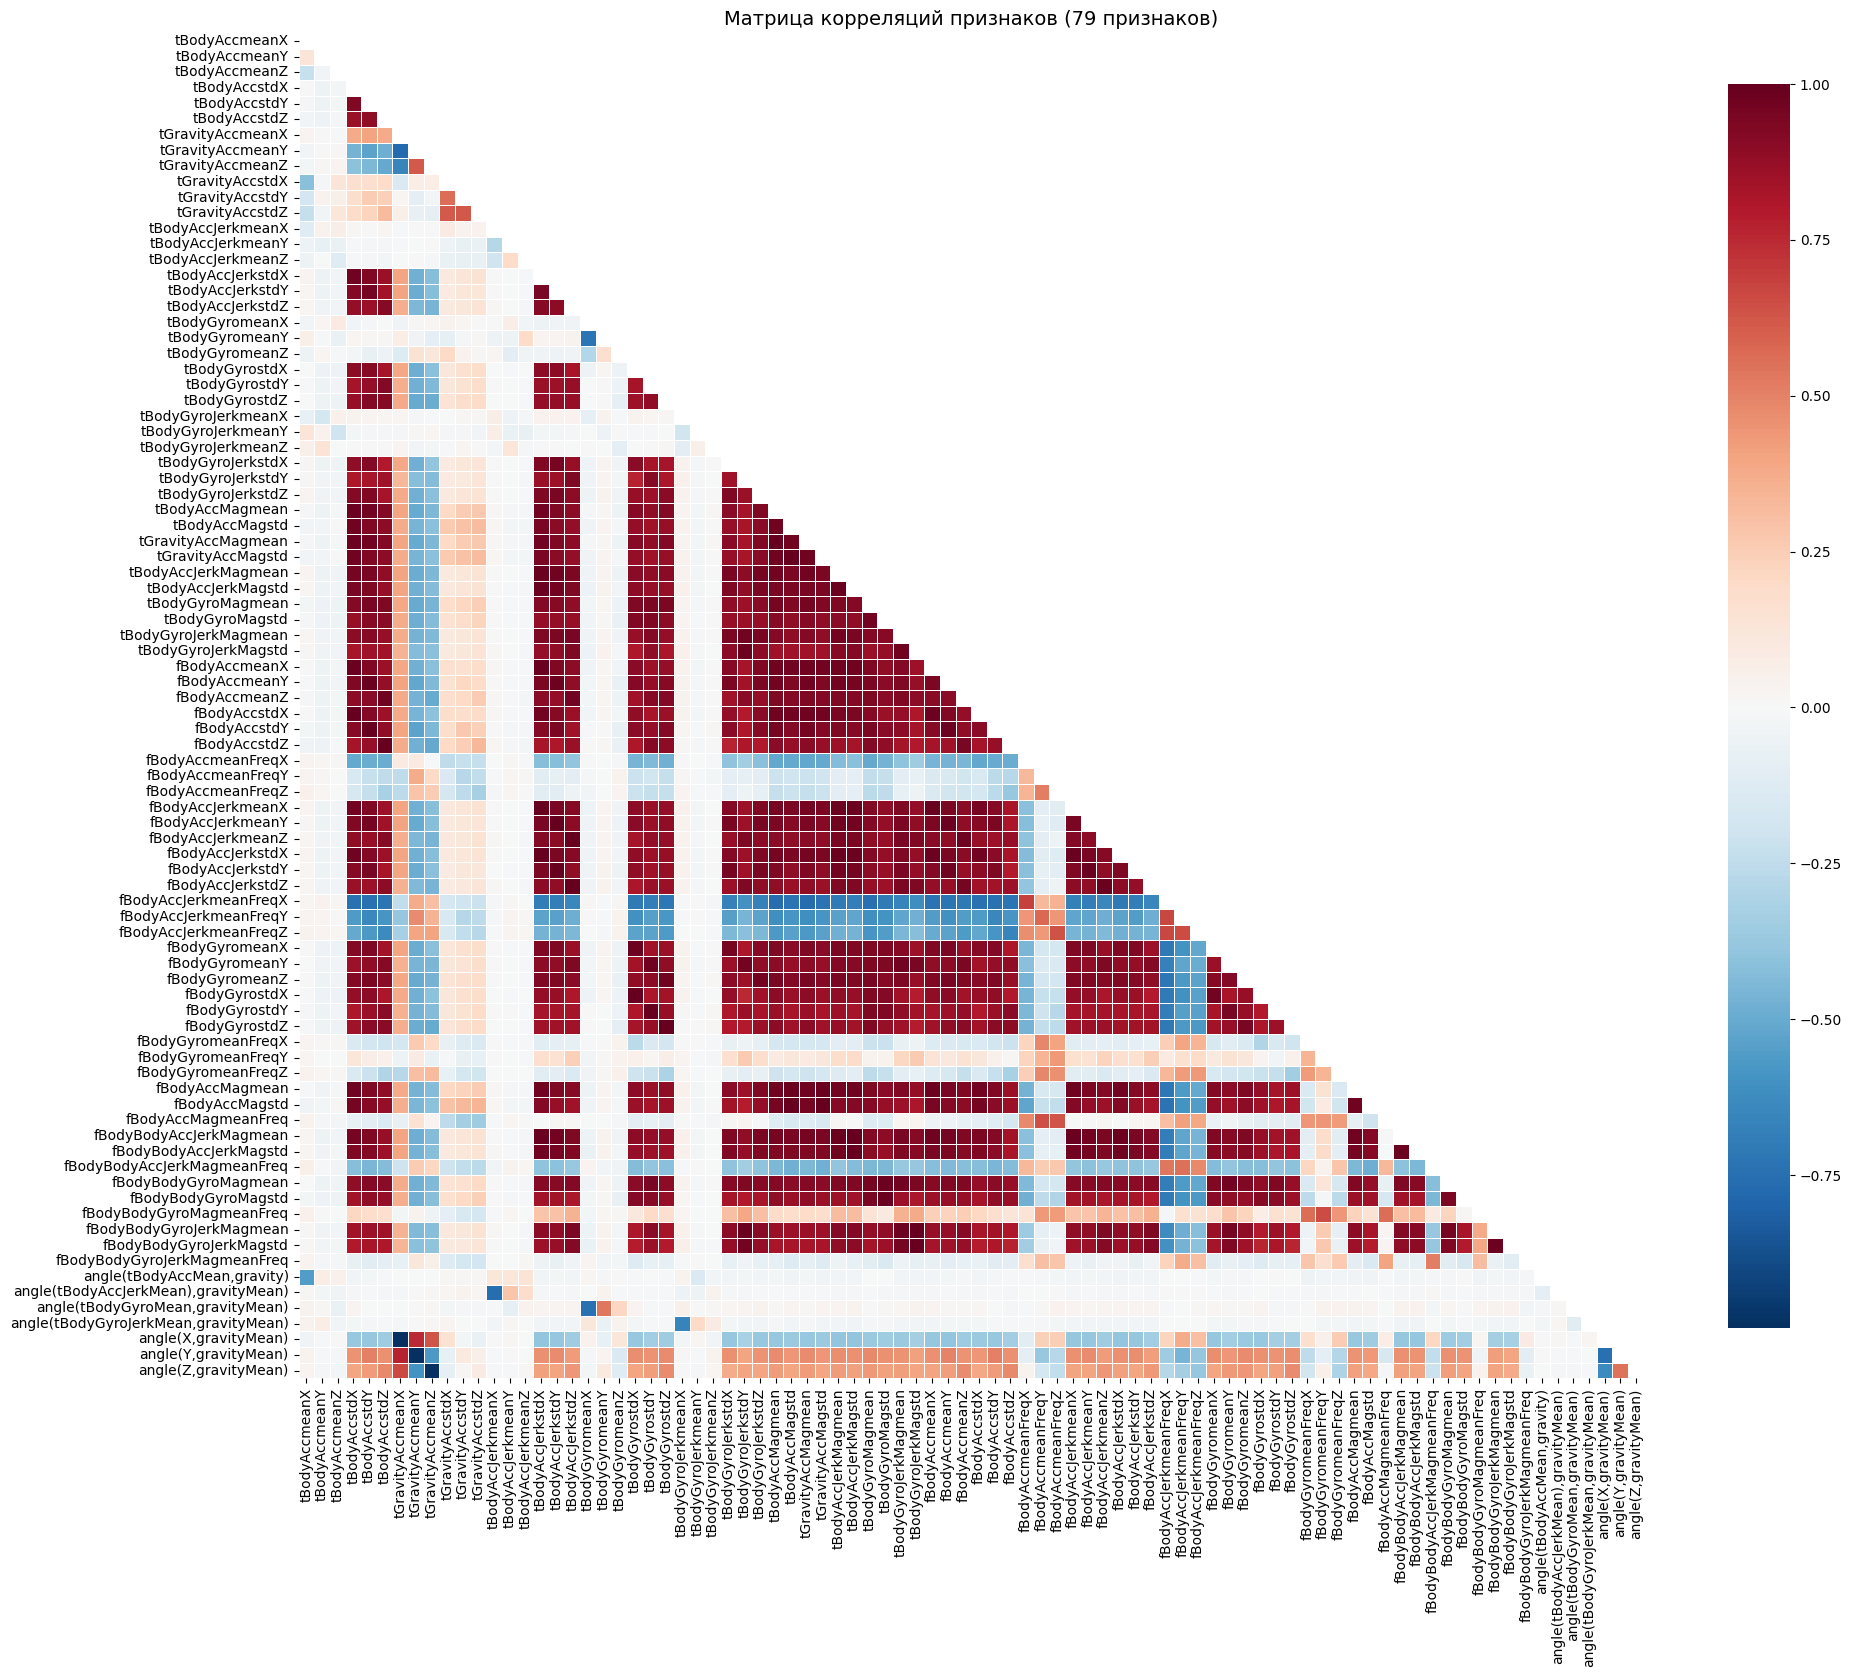

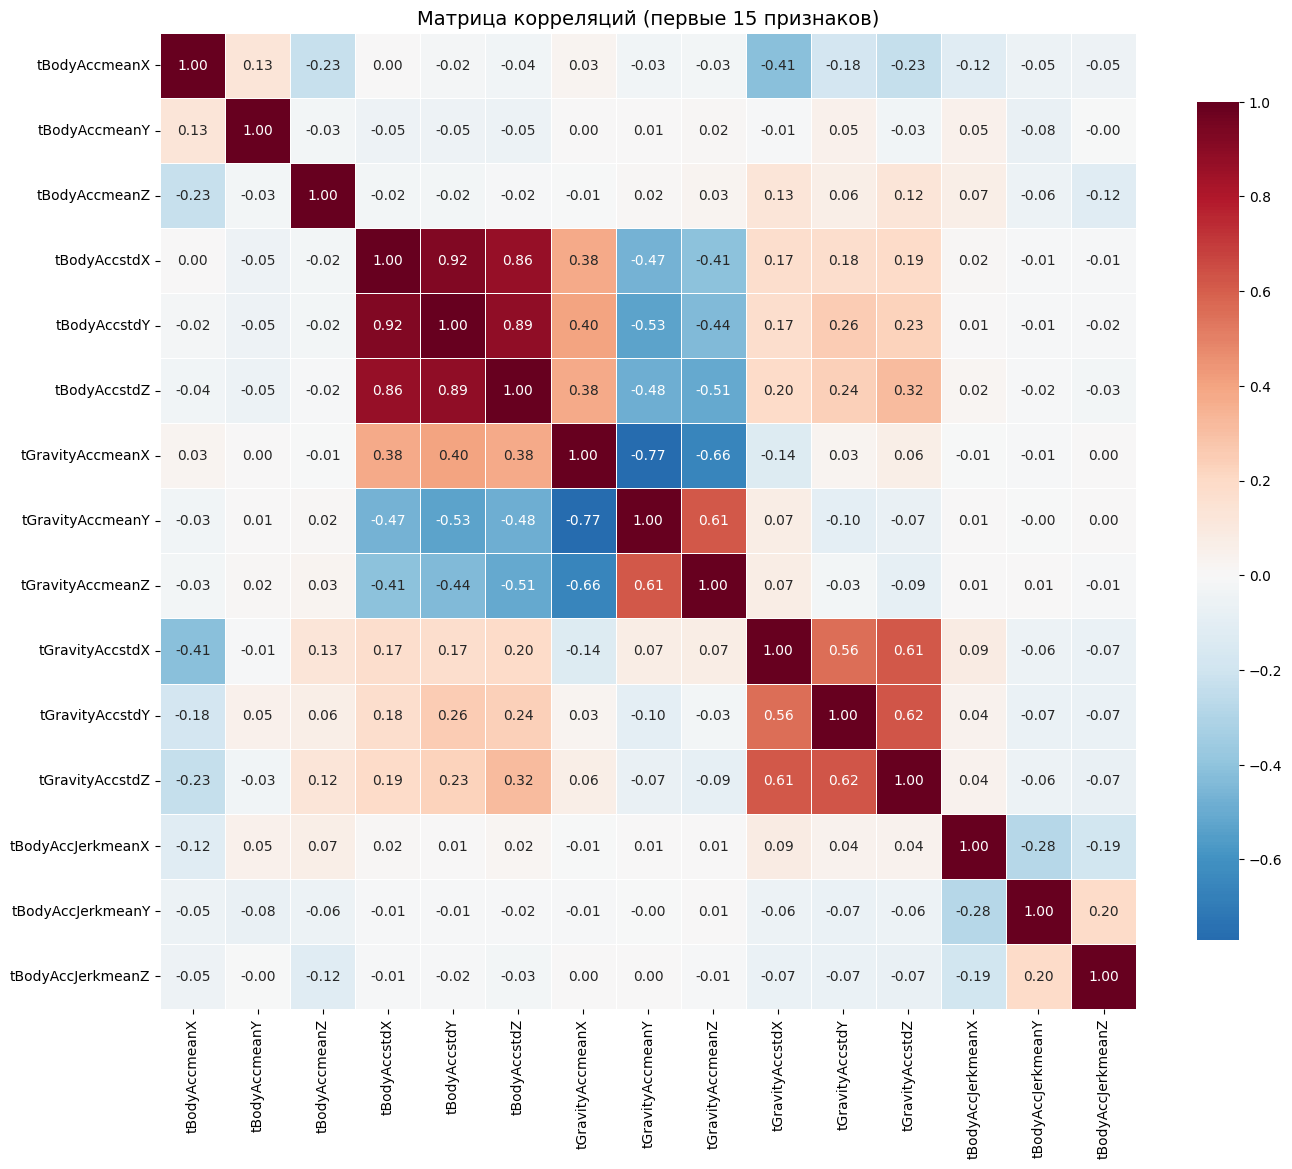


3. Анализ корреляций
Найдено пар признаков с |r| > 0.9: 569

10 наиболее сильно коррелированных пар:
         Признак 1               Признак 2  Корреляция
   tBodyAccMagmean      tGravityAccMagmean    1.000000
    tBodyAccMagstd       tGravityAccMagstd    1.000000
      tBodyAccstdX            fBodyAccstdX    0.998528
      tBodyAccstdY            fBodyAccstdY    0.997683
     tBodyGyrostdX           fBodyGyrostdX    0.997529
  tBodyAccJerkstdY       fBodyAccJerkmeanY    0.997381
  tBodyAccJerkstdX       fBodyAccJerkmeanX    0.997254
  tBodyAccJerkstdZ       fBodyAccJerkmeanZ    0.997227
tBodyAccJerkMagstd fBodyBodyAccJerkMagmean    0.997065
  tBodyAccJerkstdY        fBodyAccJerkstdY    0.996971


In [24]:
# Вычисляем матрицу корреляций (всех 79 признаков)
corr_matrix = X.corr()
# Визуализируем матрицу корреляций (все 79 признаков)
plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков (79 признаков)', fontsize=14)
plt.tight_layout()
plt.show()

# Для наглядности покажем матрицу корреляций для первых 15 признаков с подписями
plt.figure(figsize=(14, 12))
first_15_features = X.columns[:15]
corr_matrix_15 = X[first_15_features].corr()
sns.heatmap(corr_matrix_15, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций (первые 15 признаков)', fontsize=14)
plt.tight_layout()
plt.show()

# Анализ сильных корреляций
print("\n3. Анализ корреляций")

# Находим пары признаков с высокой корреляцией (>0.9 или <-0.9)
threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('Корреляция', ascending=False)

print(f"Найдено пар признаков с |r| > {threshold}: {len(high_corr_df)}")
print("\n10 наиболее сильно коррелированных пар:")
print(high_corr_df.head(10).to_string(index=False))


№1.3

Вопрос 1: Есть ли сильно коррелированные признаки?
Да, обнаружено 569 пар признаков с коэффициентом корреляции |r| > 0.9. Это ожидаемо, так как многие признаки представляют собой разные статистические характеристики одних и тех же сигналов.Например, признак tBodyAcc-mean()-X (среднее ускорение по оси X) и признак tBodyAcc-energy()-X (энергия сигнала по оси X) описывают один и тот же физический процесс движения, поэтому их значения тесно связаны.

Вопрос 2: Можно ли предположить, что часть признаков содержит избыточную информацию?
Да, наличие большого количества сильно коррелированных пар признаков свидетельствует о высокой избыточности данных. Это означает, что:
Многие признаки измеряют схожие свойства сигнала(Например, для описания движения достаточно знать либо среднее значение, либо энергию сигнала — они почти одинаковы.);
Размерность данных можно существенно снизить без большой потери информации;
Применение методов снижения размерности (PCA, t-SNE, UMAP) обосновано — они позволят заменить 79 исходных признаков меньшим количеством новых признаков (главных компонент), сохранив основную структуру данных.

Проведенный анализ геометрии данных подтверждает, что датасет имеет высокую размерность (79 признаков) при значительной избыточности (многие признаки дублируют информацию). Это создает предпосылки для успешного применения методов снижения размерности в последующих заданиях лабораторной работы.

№2. Реализация PCA.

№2.1
Если два признака сильно связаны между собой, то PCA поможет нам найти новую ось, которая лучше всего описывает наши данные. PCA ищет направления максимальной дисперсии в данных.
1)Стандартизация данных.Если признаки имеют разные масштабы (например, один от 0 до 1, а другой от 0 до 1000), то признаки с большими значениями будут доминировать. Каждый признак преобразуем так, чтобы его среднее стало 0, а стандартное отклонение — 1.(метод Z-score).
2)Вычисление ковариационной матрицы. Ковариация показывает, как два признака изменяются вместе. Ковариационная матрица — это "сердце" PCA. Она показывает нам, какие признаки связаны друг с другом. PCA будет искать направления в пространстве этих связей.
3)Нахождение собственных значений и собственных векторов. Собственные векторы — это новые оси (главные компоненты), которые PCA находит. Собственные значения показывают, сколько информации (дисперсии) "лежит" вдоль каждой новой оси. λ
Сумма всех собственных значений	равна общей дисперсии всех исходных признаков.
Т.Е. Шаг 2: мы создаем "карту связей" между всеми признаками
Шаг 3: мы находим на этой карте "главные направления".

4) Сортировка компонент по убыванию собственных значений.(т.к. чем больше собственное значение, тем важнее компонента.)
5)Проекция данных на первые k компонент.X — исходные данные,W — матрица новых осей (главных компонент).PCA нашел k новых направления (главных компоненты) в наших данных. Каждое направление описывается k числами.
X_new — сжатые данные. Мы берем исходные данные и "проецируем" их на новые оси.

In [57]:

X = df.drop(['subject', 'activities'], axis=1)

print(f"\nИсходная форма данных: {X.shape}")
print(f"  Количество признаков: {X.shape[1]}")

# Преобразуем в numpy массив
X_np = X.values.astype(float)

print("ШАГ 1: СТАНДАРТИЗАЦИЯ ДАННЫХ")

# Вычисляем среднее и стандартное отклонение
mean = np.mean(X_np, axis=0)
std = np.std(X_np, axis=0)

# Защита от деления на ноль
std[std == 0] = 1

# Стандартизация
X_scaled = (X_np - mean) / std

print(f"  Средние значения (первые 5): {mean[:5]}")
print(f"  Стандартные отклонения (первые 5): {std[:5]}")
print(f"  После стандартизации: среднее = {np.mean(X_scaled[:, 0]):.2e}, "
      f"стандартное отклонение = {np.std(X_scaled[:, 0]):.2f}")

print("ШАГ 2: ВЫЧИСЛЕНИЕ КОВАРИАЦИОННОЙ МАТРИЦЫ")


n_samples = X_scaled.shape[0]
n_features = X_scaled.shape[1]

# Ковариационная матрица
cov_matrix = (1 / (n_samples - 1)) * np.dot(X_scaled.T, X_scaled)

print(f"  Размер ковариационной матрицы: {cov_matrix.shape}")
print(f"  Ковариационная матрица (первые 5x5):")
print(np.round(cov_matrix[:5, :5], 4))

print("ШАГ 3: НАХОЖДЕНИЕ СОБСТВЕННЫХ ЗНАЧЕНИЙ И СОБСТВЕННЫХ ВЕКТОРОВ")


# Вычисляем собственные значения и собственные векторы
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Преобразуем в действительные числа
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print(f"  Количество собственных значений: {len(eigenvalues)}")
print(f"  Собственные значения (первые 10):")
print(f"    {np.round(eigenvalues[:10], 6)}")

print("ШАГ 4: СОРТИРОВКА КОМПОНЕНТ ПО УБЫВАНИЮ СОБСТВЕННЫХ ЗНАЧЕНИЙ")


# Получаем индексы для сортировки по убыванию
idx_sorted = np.argsort(eigenvalues)[::-1]

# Сортируем собственные значения и собственные векторы
eigenvalues_sorted = eigenvalues[idx_sorted]
eigenvectors_sorted = eigenvectors[:, idx_sorted]

print(f"  Собственные значения после сортировки (первые 10):")
print(f"    {np.round(eigenvalues_sorted[:10], 6)}")


print("ШАГ 5: ПРОЕКЦИЯ ДАННЫХ НА ПЕРВЫЕ k КОМПОНЕНТ")

# Выбираем количество компонент
k = 2

# Берем первые k собственных векторов
components = eigenvectors_sorted[:, :k]

# Проекция данных
X_projected = np.dot(X_scaled, components)

print(f"  Выбрано компонент: k = {k}")
print(f"  Размер матрицы компонент: {components.shape}")
print(f"  Размерность спроецированных данных: {X_projected.shape}")
print(f"  Первые 5 спроецированных объектов:")
print(np.round(X_projected[:5], 4))

print("\nСРАВНЕНИЕ С sklearn.decomposition.PCA")

# Обучаем PCA из sklearn
pca_sklearn = SklearnPCA(n_components=k)
X_projected_sklearn = pca_sklearn.fit_transform(X_np)

# Получаем компоненты из sklearn
components_sklearn = pca_sklearn.components_.T

print(f"\n Сравнение главных компонент (k = {k}):")

# Вычисляем корреляции
correlation_pc1 = np.corrcoef(components[:, 0], components_sklearn[:, 0])[0, 1]
correlation_pc2 = np.corrcoef(components[:, 1], components_sklearn[:, 1])[0, 1]

print(f"  Корреляция между PC1 (NumPy) и PC1 (sklearn): {correlation_pc1:.10f}")
print(f"  Корреляция между PC2 (NumPy) и PC2 (sklearn): {correlation_pc2:.10f}")


print(f"\n Корректировка знака для сравнения проекций:")

# Определяем знак для каждой компоненты
sign_adjust = np.ones(k)
if correlation_pc1 < 0:
    sign_adjust[0] = -1
    print(f"  PC1: знак инвертирован (был {correlation_pc1:.4f} → стал 1.0)")
if correlation_pc2 < 0:
    sign_adjust[1] = -1
    print(f"  PC2: знак инвертирован (был {correlation_pc2:.4f} → стал 1.0)")

# Применяем коррекцию знака к нашим компонентам и проекции
components_corrected = components * sign_adjust
X_projected_corrected = X_projected * sign_adjust

# Пересчитываем корреляции после коррекции
corr_pc1_corrected = np.corrcoef(components_corrected[:, 0], components_sklearn[:, 0])[0, 1]
corr_pc2_corrected = np.corrcoef(components_corrected[:, 1], components_sklearn[:, 1])[0, 1]

print(f"\n Корреляции после коррекции знака:")
print(f"  PC1: {corr_pc1_corrected:.10f}")
print(f"  PC2: {corr_pc2_corrected:.10f}")


print(f"\n Сравнение проекций после коррекции знака (первые 5 объектов):")
print(f"{'Объект':<8} {'NumPy PC1':<15} {'sklearn PC1':<15} {'NumPy PC2':<15} {'sklearn PC2':<15}")
for i in range(5):
    print(f"{i+1:<8} {X_projected_corrected[i, 0]:<15.6f} {X_projected_sklearn[i, 0]:<15.6f} "
          f"{X_projected_corrected[i, 1]:<15.6f} {X_projected_sklearn[i, 1]:<15.6f}")

# Вычисляем разницу
diff_pc1 = np.abs(X_projected_corrected[:, 0] - X_projected_sklearn[:, 0])
diff_pc2 = np.abs(X_projected_corrected[:, 1] - X_projected_sklearn[:, 1])


Исходная форма данных: (10299, 86)
  Количество признаков: 86
ШАГ 1: СТАНДАРТИЗАЦИЯ ДАННЫХ
  Средние значения (первые 5): [ 0.27434726 -0.01774349 -0.10892503 -0.60778382 -0.51019138]
  Стандартные отклонения (первые 5): [0.06762451 0.03712636 0.05303051 0.43867253 0.50021548]
  После стандартизации: среднее = -2.36e-16, стандартное отклонение = 1.00
ШАГ 2: ВЫЧИСЛЕНИЕ КОВАРИАЦИОННОЙ МАТРИЦЫ
  Размер ковариационной матрицы: (86, 86)
  Ковариационная матрица (первые 5x5):
[[ 1.0001  0.128  -0.2303  0.0046 -0.0168]
 [ 0.128   1.0001 -0.0299 -0.0464 -0.047 ]
 [-0.2303 -0.0299  1.0001 -0.0242 -0.0237]
 [ 0.0046 -0.0464 -0.0242  1.0001  0.9226]
 [-0.0168 -0.047  -0.0237  0.9226  1.0001]]
ШАГ 3: НАХОЖДЕНИЕ СОБСТВЕННЫХ ЗНАЧЕНИЙ И СОБСТВЕННЫХ ВЕКТОРОВ
  Количество собственных значений: 86
  Собственные значения (первые 10):
    [46.582197  5.868383  3.781454  2.546557  2.246331  1.976057  1.818879
  1.535052  1.407749  1.267275]
ШАГ 4: СОРТИРОВКА КОМПОНЕНТ ПО УБЫВАНИЮ СОБСТВЕННЫХ ЗНАЧЕНИЙ
  Со

№2.2
Доля объяснённой дисперсии показывает, какой процент информации (изменчивости) содержит каждая компонента, а накопленная дисперсия — суммарный объем информации, сохраненный при использовании заданного числа компонент.
Доля объясненной дисперсии для i-й компоненты = λᵢ / Общую дисперсию
 Накопленная дисперсия для 2 компонент = (λ1+λ2)/ Общую дисперсию


 Доля объясненной дисперсии (первые 15 компонент):
Компонента   Доля дисперсии     Накопленная доля  
PC1           0.541601           0.541601          
PC2           0.068230           0.609831          
PC3           0.043966           0.653797          
PC4           0.029608           0.683406          
PC5           0.026118           0.709523          
PC6           0.022975           0.732498          
PC7           0.021148           0.753646          
PC8           0.017848           0.771494          
PC9           0.016368           0.787861          
PC10          0.014734           0.802596          
PC11          0.013133           0.815729          
PC12          0.012207           0.827936          
PC13          0.011665           0.839601          
PC14          0.011195           0.850796          
PC15          0.010541           0.861337          


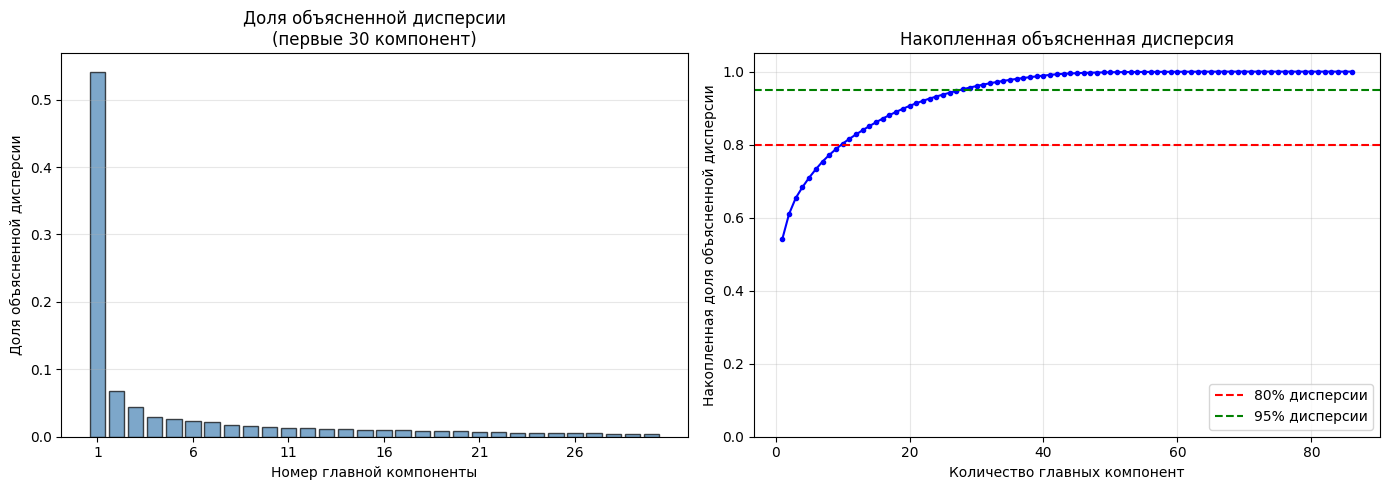

ОПРЕДЕЛЕНИЕ КОЛИЧЕСТВА КОМПОНЕНТ

 Результаты:
 Для сохранения 80% дисперсии необходимо 10 главных компонент
 Для сохранения 95% дисперсии необходимо 28 главных компонент

 Исходное количество признаков: 86
 Сжатие для 80% дисперсии: 86 → 10 (сжатие в 8.6 раз)
 Сжатие для 95% дисперсии: 86 → 28 (сжатие в 3.1 раз)
 Первая компонента объясняет 54.16% дисперсии
 Первые 5 компонент объясняют 70.95% дисперсии
 Первые 10 компонент объясняют 80.26% дисперсии
 Первые 20 компонент объясняют 90.62% дисперсии

По результатам анализа объясненной дисперсии:

1. График доли объясненной дисперсии показывает, что первая главная компонента
   вносит наибольший вклад (54.16%), затем вклад
   каждой следующей компоненты постепенно уменьшается.

2. График накопленной объясненной дисперсии позволяет определить необходимое
   количество компонент для сохранения заданной доли информации:

    -Для сохранения 80% информации достаточно 10 главных компонент
     (вместо 86 исходных признаков).

   - Для сохране

In [55]:
# Общая дисперсия = сумма всех собственных значений
total_variance = np.sum(eigenvalues_sorted)
# Вычисляем долю объясненной дисперсии для каждой компоненты
explained_variance_ratio = eigenvalues_sorted / total_variance

# Вычисляем накопленную дисперсию
cumulative_variance = np.cumsum(explained_variance_ratio)
'''cumulative_variance[0] = explained_variance_ratio[0]
cumulative_variance[1] = explained_variance_ratio[0] + explained_variance_ratio[1]
cumulative_variance[2] = explained_variance_ratio[0] + explained_variance_ratio[1] + explained_variance_ratio[2]
и так далее'''

# Выводим таблицу для отчета
print("\n Доля объясненной дисперсии (первые 15 компонент):")
print(f"{'Компонента':<12} {'Доля дисперсии':<18} {'Накопленная доля':<18}")
for i in range(min(15, len(explained_variance_ratio))):
    print(f"PC{i+1:<11} {explained_variance_ratio[i]:<18.6f} {cumulative_variance[i]:<18.6f}")


# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Доля объясненной дисперсии (столбчатая диаграмма)
n_components_to_plot = min(30, len(explained_variance_ratio))  # показываем первые 30 компонент

ax1.bar(range(1, n_components_to_plot + 1), 
        explained_variance_ratio[:n_components_to_plot], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Номер главной компоненты')
ax1.set_ylabel('Доля объясненной дисперсии')
ax1.set_title('Доля объясненной дисперсии\n(первые 30 компонент)')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(range(1, n_components_to_plot + 1, 5))
ax1.set_xticklabels(range(1, n_components_to_plot + 1, 5))

# График 2: Накопленная объясненная дисперсия (линейный график)
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         'b-o', markersize=3, linewidth=1.5)
ax2.axhline(y=0.8, color='r', linestyle='--', linewidth=1.5, label='80% дисперсии')
ax2.axhline(y=0.95, color='g', linestyle='--', linewidth=1.5, label='95% дисперсии')
ax2.set_xlabel('Количество главных компонент')
ax2.set_ylabel('Накопленная доля объясненной дисперсии')
ax2.set_title('Накопленная объясненная дисперсия')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


print("ОПРЕДЕЛЕНИЕ КОЛИЧЕСТВА КОМПОНЕНТ")
# Находим количество компонент для 80% и 95% дисперсии
n_80 = np.argmax(cumulative_variance >= 0.8) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n Результаты:")
print(f" Для сохранения 80% дисперсии необходимо {n_80} главных компонент")
print(f" Для сохранения 95% дисперсии необходимо {n_95} главных компонент")
print(f"\n Исходное количество признаков: {X.shape[1]}")
print(f" Сжатие для 80% дисперсии: {X.shape[1]} → {n_80} (сжатие в {X.shape[1]/n_80:.1f} раз)")
print(f" Сжатие для 95% дисперсии: {X.shape[1]} → {n_95} (сжатие в {X.shape[1]/n_95:.1f} раз)")

print(f" Первая компонента объясняет {explained_variance_ratio[0]:.2%} дисперсии")
print(f" Первые 5 компонент объясняют {np.sum(explained_variance_ratio[:5]):.2%} дисперсии")
print(f" Первые 10 компонент объясняют {np.sum(explained_variance_ratio[:10]):.2%} дисперсии")
print(f" Первые 20 компонент объясняют {np.sum(explained_variance_ratio[:20]):.2%} дисперсии")


print(f"""
По результатам анализа объясненной дисперсии:

1. График доли объясненной дисперсии показывает, что первая главная компонента
   вносит наибольший вклад ({explained_variance_ratio[0]:.2%}), затем вклад
   каждой следующей компоненты постепенно уменьшается.

2. График накопленной объясненной дисперсии позволяет определить необходимое
   количество компонент для сохранения заданной доли информации:
   
    -Для сохранения 80% информации достаточно {n_80} главных компонент
     (вместо {X.shape[1]} исходных признаков).
   
   - Для сохранения 95% информации требуется {n_95} главных компонент.

3. Это подтверждает, что данные обладают избыточностью, и методы снижения
   размерности эффективны для сжатия информации.
""")

Для 80%: Складываем λ, пока сумма не станет ≥ 0.8 × 86 = 68.8
46.58 + 5.87 = 52.45
+3.78 = 56.23
+2.55 = 58.78
+2.25 = 61.03
+1.98 = 63.01
+1.82 = 64.83
+1.54 = 66.37
+1.41 = 67.78
+1.27 = 69.05 ≥ 68.8 
Ответ: 10 компонент
Это означает, что 10 новых признаков (главных компонент) содержат 80% информации исходных 86 признаков. Сжатие составляет 8.6 раза.
Для 95%:95% от 86 = 81.7
После 28 компонент сумма достигает 81.8
Ответ: 28 компонент.Для более точного представления нужно больше компонент, но сжатие все еще существенное


Первые 10 компонент уже описывают основную структуру данных.Остальные 76 компонент вносят малый вклад (в сумме 20% дисперсии).Это подтверждает избыточность исходных признаков и эффективность PCA

№3. Интерпретация главных компонент.

Коэффициент показывает, сколько признака нужно добавить в компоненту.
Каждая главная компонента — это линейная комбинация исходных признаков:
PC1 = w₁ × признак₁ + w₂ × признак₂ + ... + w₈₆ × признак₈₆
где wᵢ — это коэффициент (вес) i-го признака в первой компоненте.

In [61]:
print("ЗАДАНИЕ 3: ИНТЕРПРЕТАЦИЯ ГЛАВНЫХ КОМПОНЕНТ")

# components_corrected — это матрица, где столбцы — компоненты, строки — признаки
# У нас components_corrected.shape = (86, 2) для k=2, но нам нужны первые 3 компоненты

print("\n1. КОЭФФИЦИЕНТЫ ПРИЗНАКОВ В ПЕРВЫХ ТРЕХ КОМПОНЕНТАХ")

# пересчитаем проекцию для 3 компонент

# Берем первые 3 компоненты
k_interpret = 3
components_3 = eigenvectors_sorted[:, :k_interpret]# вот коэффициенты

print(f"\n Матрица коэффициентов имеет размерность: {components_3.shape}")
print(f"   {components_3.shape[0]} строк — исходные признаки")
print(f"   {components_3.shape[1]} столбцов — главные компоненты (PC1, PC2, PC3)")

# Создаем DataFrame для удобного просмотра
import pandas as pd
coeff_df = pd.DataFrame(
    components_3,
    columns=[f'PC{i+1}' for i in range(k_interpret)],
    index=X.columns  # названия признаков
)

print(f"\n Первые 10 признаков и их коэффициенты:")
print(coeff_df.head(10).round(4))


print("2. ПРИЗНАКИ С НАИБОЛЬШИМ ВКЛАДОМ В КАЖДУЮ КОМПОНЕНТУ")
# Для каждой компоненты находим 10 признаков с наибольшими коэффициентами (по модулю)
for i in range(k_interpret):
    pc_name = f'PC{i+1}'
    # Сортируем по абсолютному значению коэффициента
    top_features = coeff_df[pc_name].abs().sort_values(ascending=False).head(10)
    
    print(f"\n {pc_name}:")
    print(f"  10 признаков с наибольшим вкладом:")
    for idx, (feature, value) in enumerate(top_features.items(), 1):
# Показываем знак коэффициента(Признак и компонента растут вместе если знак положительный, и признак и компонента растут в разные стороны если наоборот)
        actual_value = coeff_df.loc[feature, pc_name]
        sign = "+" if actual_value > 0 else "-"
        print(f"   {idx:2}. |{actual_value:.4f}| → {feature[:50]} (знак: {sign})")
    
    # Вычисляем, сколько признаков имеют нулевой вклад
    zero_count = np.sum(np.abs(coeff_df[pc_name]) < 1e-6)
    if zero_count > 0:
        print(f"\n   Признаков с коэффициентом ≈ 0: {zero_count}")


ЗАДАНИЕ 3: ИНТЕРПРЕТАЦИЯ ГЛАВНЫХ КОМПОНЕНТ

1. КОЭФФИЦИЕНТЫ ПРИЗНАКОВ В ПЕРВЫХ ТРЕХ КОМПОНЕНТАХ

 Матрица коэффициентов имеет размерность: (86, 3)
   86 строк — исходные признаки
   3 столбцов — главные компоненты (PC1, PC2, PC3)

 Первые 10 признаков и их коэффициенты:
                     PC1     PC2     PC3
tBodyAccmeanX     0.0004 -0.0519 -0.1216
tBodyAccmeanY     0.0071  0.0017 -0.0124
tBodyAccmeanZ     0.0045  0.0179  0.0498
tBodyAccstdX     -0.1400 -0.0180  0.0337
tBodyAccstdY     -0.1417  0.0154  0.0199
tBodyAccstdZ     -0.1369  0.0407  0.0242
tGravityAccmeanX -0.0644  0.1088 -0.3784
tGravityAccmeanY  0.0794 -0.1310  0.3131
tGravityAccmeanZ  0.0724 -0.0847  0.3171
tGravityAccstdX  -0.0225  0.0984  0.2848
2. ПРИЗНАКИ С НАИБОЛЬШИМ ВКЛАДОМ В КАЖДУЮ КОМПОНЕНТУ

 PC1:
  10 признаков с наибольшим вкладом:
    1. |-0.1437| → tBodyAccJerkMagmean (знак: -)
    2. |-0.1436| → tBodyAccMagmean (знак: -)
    3. |-0.1436| → tGravityAccMagmean (знак: -)
    4. |-0.1426| → fBodyBodyAccJerkMagm

1.Какие признаки больше всего влияют на первую компоненту?
На первую компоненту (PC1) больше всего влияют признаки, связанные с модульными величинами (Mag) и средними значениями (mean) сигналов. Все они имеют отрицательные коэффициенты примерно от -0.141 до -0.143.
5 признаков, оказывающих наибольшее влияние:
tBodyAccJerkMagmean — среднее значение рывка (изменения ускорения) по модулю
tBodyAccMagmean — среднее значение ускорения по модулю
tGravityAccMagmean — среднее значение гравитационной составляющей по модулю
fBodyBodyAccJerkMagmean — среднее значение рывка в частотной области
fBodyAccmeanY — среднее значение ускорения по оси Y в частотной области

Общая характеристика: PC1 определяется общей интенсивностью движений (чем активнее человек, тем больше значения этих признаков, и тем меньше становится PC1 из-за отрицательных коэффициентов).

2.Можно ли интерпретировать первую компоненту как некоторую 
комбинацию исходных признаков? 
Да, первую главную компоненту можно интерпретировать как линейную комбинацию исходных признаков, потому что по определению метода главных компонент (PCA) каждая компонента представляет собой взвешенную сумму всех исходных признаков, где веса — это коэффициенты из собственного вектора, и в случае PC1 = 0.0004×tBodyAccmeanX + 0.0071×tBodyAccmeanY + ... + (-0.1437)×tBodyAccJerkMagmean + ... — то есть это просто формула, где каждый исходный признак умножается на свой коэффициент, и все эти произведения складываются, образуя новую переменную, которая затем может быть осмысленно названа, например, «индикатором общей активности».
Кроме этого, Каждая компонента — это просто взвешенная сумма всех 86 признаков, но с разными весами. Разница между компонентами — в коэффициентах, которые определяют, какая комбинация признаков наиболее важна для описания данных с разных сторон.

3.Есть ли признаки, которые практически не влияют на первые компоненты? 
Да, есть. Чтобы определить это, нужно посмотреть на признаки с коэффициентами, близкими к 0 (по модулю) во всех трех компонентах.
Признаки tBodyAccmeanX, tBodyAccmeanY, tBodyAccmeanZ (средние значения ускорения по осям X, Y, Z) практически не влияют на первые три компоненты, потому что их коэффициенты близки к 0.
Почему это важно:
Эти признаки содержат мало информации для разделения активностей,
Их можно исключить без существенной потери информации,
Это подтверждает избыточность данных.

PC1 — Компонента "Общая интенсивность движений.
Так как все коэффициенты отрицательные, это означает:
PC1 = -(0.14 × признак + 0.14 × признак + ...)
Большое положительное - Все признаки маленькие → человек не двигается (сидит, лежит)
Большое отрицательное - Все признаки большие → человек активно двигается (ходит, бежит)
Вывод: PC1 — это индикатор активности. Чем меньше PC1, тем активнее движение.

PC2 — Компонента "Частотные характеристики движения"
Все признаки из списка:начинаются с f (частотная область), содержат meanFreq (средняя частота), характеризуют ритмичность и частоту движений.
Так как все коэффициенты тоже отрицательные: 
Большое положительное - Частоты низкие → движения медленные, плавные
Большое отрицательное - Частоты высокие → движения быстрые, ритмичные
Вывод: PC2 — это индикатор ритмичности движений. Чем меньше PC2, тем быстрее и ритмичнее движение (например, бег). Чем больше PC2, тем медленнее движение (например, ходьба или стояние).

PC3 — Компонента "Ориентация в пространстве (гравитация)"
В списке есть: tGravityAcc — гравитационная составляющая акселерометра (показывает наклон телефона);angle(..., gravityMean) — углы между осями и направлением гравитации; признаки, связанные с ориентацией устройства в пространстве.
Большое положительное - Тело находится в вертикальном положении (стояние, ходьба)
Большое отрицательное - Тело находится в горизонтальном положении (лежание, сидение с наклоном)
Вывод: PC3 — это индикатор позы/ориентации человека. Положительные значения соответствуют вертикальному положению (стояние, ходьба), отрицательные — горизонтальному (лежание).

№4. Визуализация данных.


1. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ИСХОДНЫМ ПРИЗНАКАМ

2. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ГЛАВНЫМ КОМПОНЕНТАМ
   Объясненная дисперсия:
   PC1: 66.72%
   PC2: 6.41%
   Суммарно: 73.13%


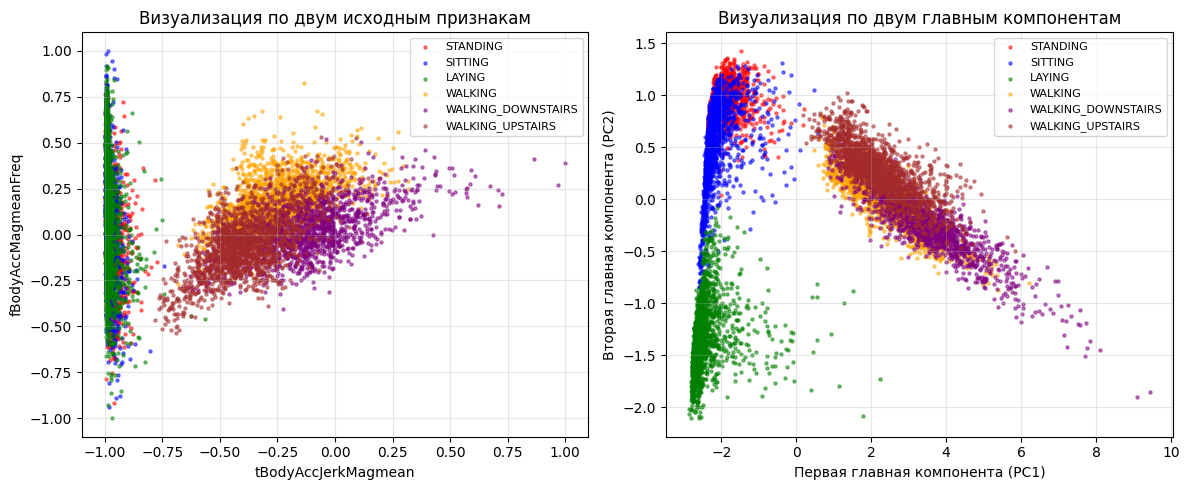

In [63]:
print("\n1. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ИСХОДНЫМ ПРИЗНАКАМ")

# Возьмем признаки, которые имеют наибольшие коэффициенты в PC1 и PC2

# признаки, которые сильно коррелируют с PC1 и PC2
#  tBodyAccJerkMagmean (важный для PC1) и fBodyAccMagmeanFreq (важный для PC2)
feature1 = 'tBodyAccJerkMagmean'
feature2 = 'fBodyAccMagmeanFreq'

# Проверяем, есть ли эти признаки в датасете
if feature1 not in X.columns or feature2 not in X.columns:
    # Если нет, берем первые два числовых признака
    feature1 = X.columns[0]
    feature2 = X.columns[1]
    print(f"   Используем признаки: {feature1} и {feature2}")

X_feature1 = X[feature1].values
X_feature2 = X[feature2].values

# Создаем словарь цветов для разных активностей
activities = y.unique()
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
activity_colors = {act: colors[i % len(colors)] for i, act in enumerate(activities)}

# Визуализация по исходным признакам
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for activity in activities:
    mask = y == activity
    plt.scatter(X_feature1[mask], X_feature2[mask], 
                c=activity_colors[activity], label=activity, alpha=0.5, s=5)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Визуализация по двум исходным признакам')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)


print("\n2. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ГЛАВНЫМ КОМПОНЕНТАМ")

# Обучаем PCA
pca = SklearnPCA(n_components=2)
X_pca = pca.fit_transform(X_np)

print(f"   Объясненная дисперсия:")
print(f"   PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"   Суммарно: {sum(pca.explained_variance_ratio_):.2%}")

# Визуализация по главным компонентам
plt.subplot(1, 2, 2)
for activity in activities:
    mask = y == activity
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=activity_colors[activity], label=activity, alpha=0.5, s=5)
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('Визуализация по двум главным компонентам')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


На визуализации по исходным признакам:
   - Объекты разных классов (активностей) сильно перемешаны
   - Границы между классами нечеткие, размытые
   - Трудно выделить отдельные группы

На визуализации по главным компонентам:
   - Объекты разных классов лучше разделены
   - Видны четкие кластеры (особенно для статических и динамических активностей)
   - Динамические активности (ходьба, подъем/спуск) расположены вместе
   - Статические активности (сидение, стояние, лежание) расположены отдельно

Вопрос 1: Улучшилась ли визуализация после PCA?
ДА, визуализация значительно улучшилась. На графике по исходным признакам классы сильно перемешаны,невозможно четко выделить группы. Например, ходьба и подъем по лестнице накладываются друг на друга, сидение и стояние трудно различить.
    
На графике по главным компонентам классы разделены гораздо лучше:
    - Динамические активности (ходьба, подъем/спуск) образуют одну область
    - Статические активности (сидение, стояние, лежание) — отдельные области
    - Границы между классами стали более четкими

Вопрос 2: Почему в пространстве главных компонент структура может быть заметнее?
1)PCA направлен на сохранение максимальной дисперсии данных.Первые две компоненты концентрируют в себе наиболее важную информацию, отбрасывая шум и менее значимые вариации.
    
2)PCA решает проблему корреляции признаков. Исходные признаки часто коррелируют между собой, что создает "размытость" на графиках. Главные компоненты ортогональны (не коррелируют), что делает структуру более четкой.
    
3)PCA позволяет визуализировать данные в пространстве,где оси (компоненты) имеют содержательный смысл (например, PC1 — интенсивность движений, PC2 — ритмичность). Это помогает увидеть закономерности, которые не видны при взгляде на отдельные исходные признаки.
    
4)При визуализации по исходным признакам мы вынуждены рассматривать только 2 из 86 измерений, теряя информацию об остальных 84. PCA объединяет всю информацию в первые компоненты, показывая наиболее важные аспекты данных.

№5. Нелинейные методы снижения размерности.

t-SNE — это метод, который сохраняет вероятностные распределения соседства. Простыми словами:
В исходном пространстве для каждой точки вычисляется, насколько вероятно, что другие точки являются ее "соседями".
В новом пространстве (2D или 3D) мы пытаемся построить такое же распределение "соседства".
Метод оптимизирует расположение точек так, чтобы эти распределения совпадали.

Perplexity — это параметр, который определяет, сколько соседей учитывается для каждой точки.

Шаг 1: Вычисляем вероятности соседства в исходном пространстве
        Для каждой точки i находим вероятность того, что точка j является ее соседом
        (используем нормальное распределение)

Шаг 2: Случайно размещаем точки в 2D-пространстве

Шаг 3: Вычисляем вероятности соседства в новом пространстве
        (используем t-распределение Стьюдента — отсюда буква "t" в названии)

Шаг 4: Оптимизируем расположение точек
        Минимизируем расхождение между двумя распределениями
        (используем градиентный спуск)

Шаг 5: Повторяем шаги 3-4 много раз, пока расположение не стабилизируется.


UMAP — это более современный метод, который сохраняет топологическую структуру данных. Простыми словами:
UMAP строит граф (сеть) связей между точками в исходном пространстве.
Этот граф представляет собой "скелет" структуры данных.
Затем UMAP находит расположение точек в низкоразмерном пространстве, которое максимально похоже на этот граф.

n_neighbors определяет, сколько ближайших соседей учитывается при построении графа.
min_dist определяет, насколько плотно могут располагаться точки в итоговой проекции.

Шаг 1: Строим граф в исходном пространстве
        Для каждой точки находим k ближайших соседей (n_neighbors)
        Соединяем точки ребрами, веса ребер = расстояния

Шаг 2: Преобразуем граф в "топологическое представление"
        Упрощаем граф, сохраняя его структуру

Шаг 3: Случайно размещаем точки в 2D-пространстве

Шаг 4: Оптимизируем расположение
        Перемещаем точки так, чтобы 2D-граф был максимально похож на исходный
        (используем кросс-энтропию и градиентный спуск)

Шаг 5: Повторяем шаг 4 много раз


 Исходные данные: 10299 объектов, 86 признаков
  Классы: ['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']

 После PCA: 50 компонент, сохранено 99.82% дисперсии
1. t-SNE (исследование perplexity)
 t-SNE с perplexity = 5...
 t-SNE с perplexity = 30...
 t-SNE с perplexity = 50...


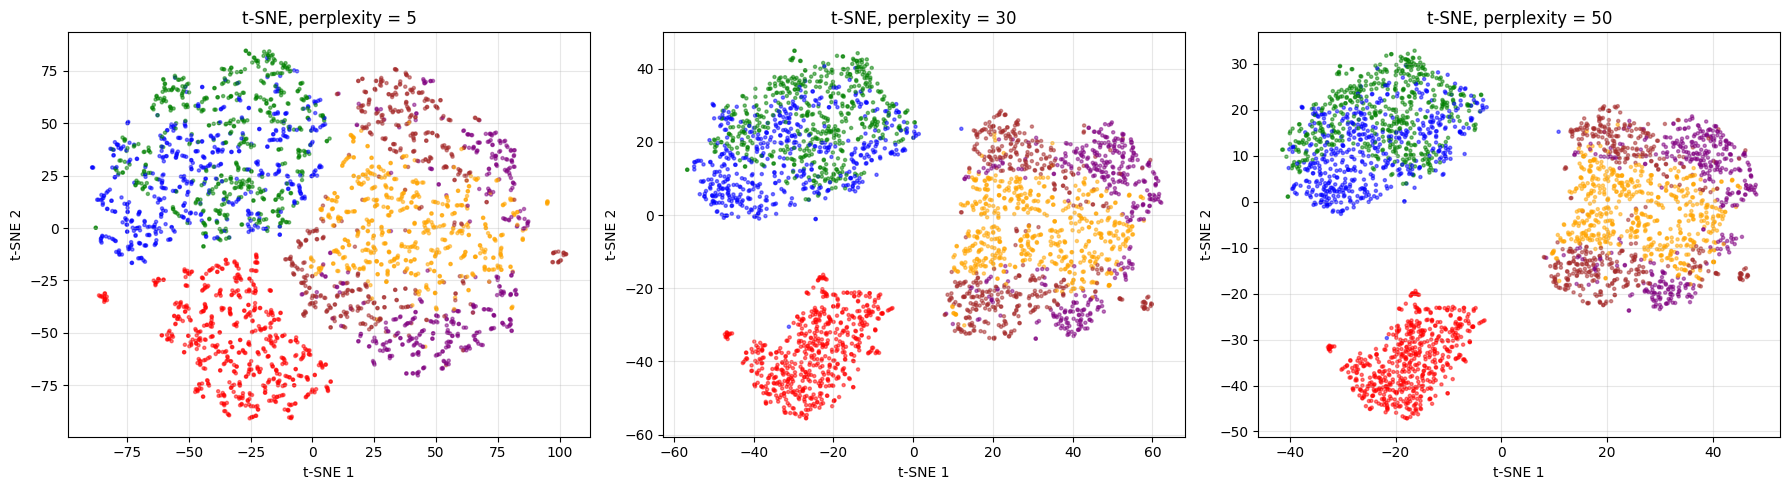

2. UMAP (исследование параметров)

 UMAP с разными n_neighbors (min_dist=0.1):
  n_neighbors = 5...
  n_neighbors = 15...
  n_neighbors = 30...


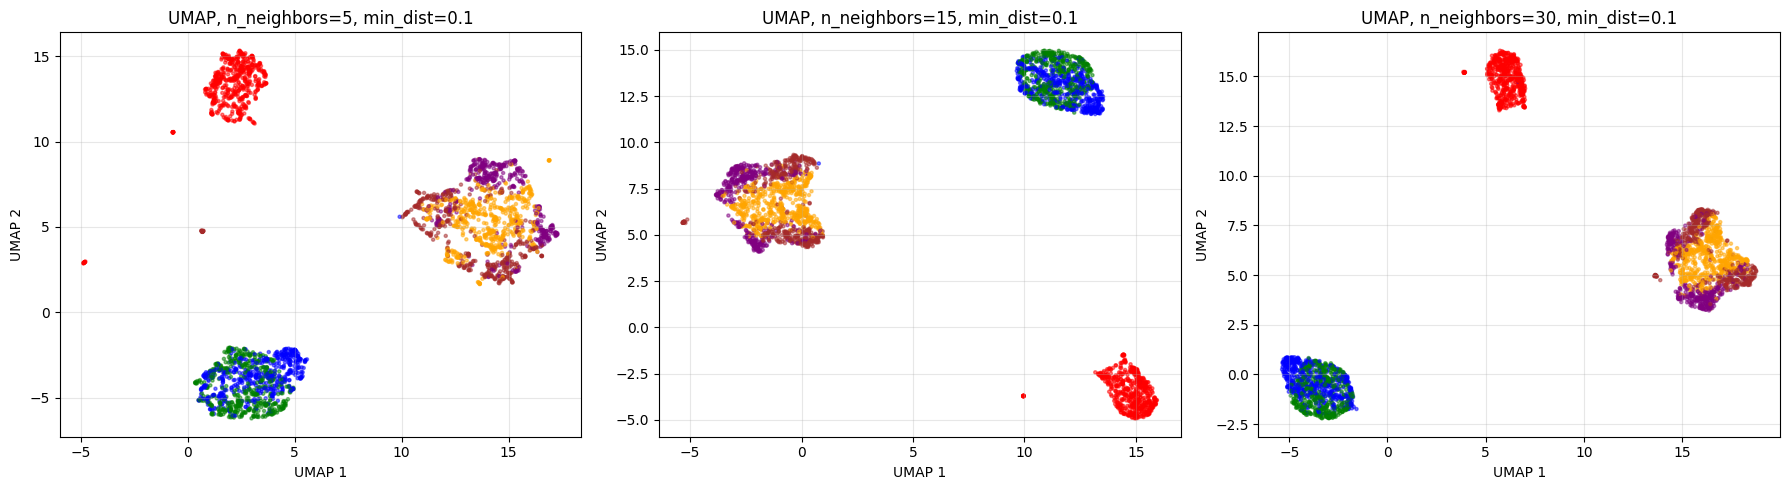


 UMAP с разными min_dist (n_neighbors=15):
  min_dist = 0.01...
  min_dist = 0.1...
  min_dist = 0.5...


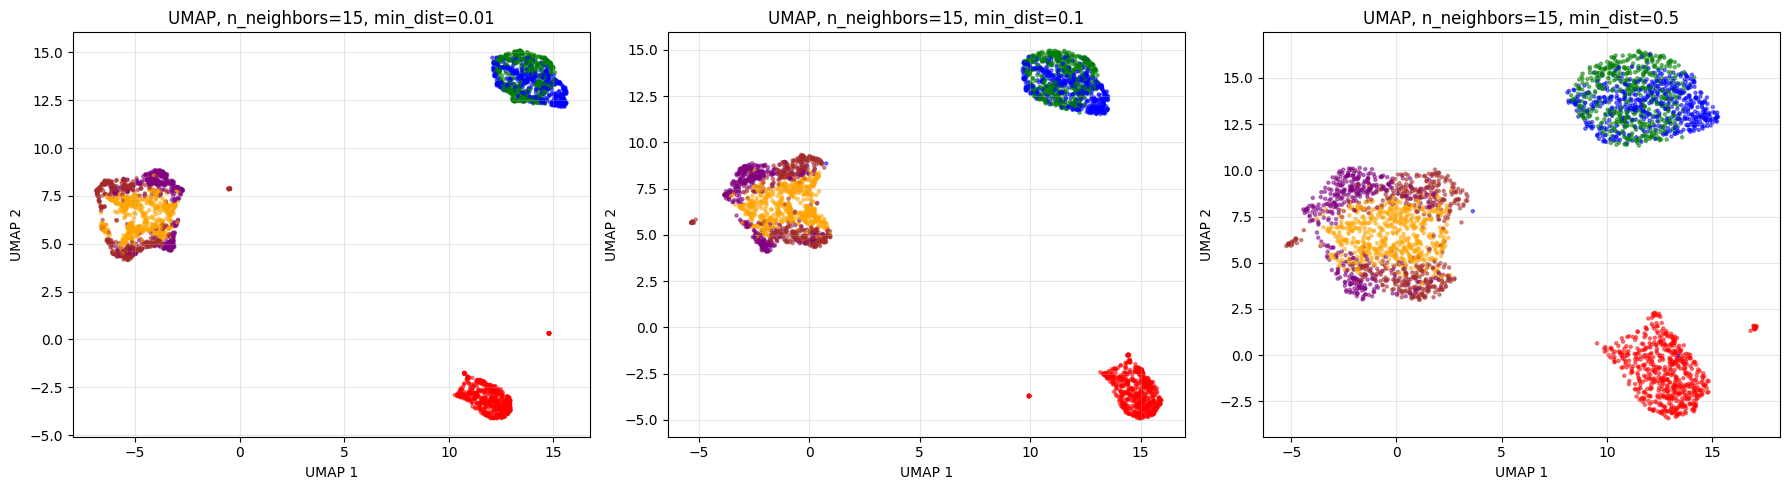

In [76]:
print(f"\n Исходные данные: {X.shape[0]} объектов, {X.shape[1]} признаков")
print(f"  Классы: {y.unique().tolist()}")

# Выборка для ускорения
np.random.seed(42)
sample_size = 3000
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X.iloc[indices].values
y_sample = y.iloc[indices].values

# Предварительное снижение размерности через PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_sample)
print(f"\n После PCA: {X_pca.shape[1]} компонент, сохранено {sum(pca.explained_variance_ratio_):.2%} дисперсии")

# Цвета для классов
activities = np.unique(y_sample)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
activity_colors = {act: colors[i % len(colors)] for i, act in enumerate(activities)}


# 1. t-SNE с разными perplexity
print("1. t-SNE (исследование perplexity)")


perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, perplexity in enumerate(perplexities):
    print(f" t-SNE с perplexity = {perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)
    
    axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=[activity_colors[a] for a in y_sample], alpha=0.5, s=5)
    axes[idx].set_title(f't-SNE, perplexity = {perplexity}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. UMAP с разными параметрами
print("2. UMAP (исследование параметров)")

# 2.1 Разные n_neighbors
print("\n UMAP с разными n_neighbors (min_dist=0.1):")
n_neighbors_values = [5, 15, 30]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n_neighbors in enumerate(n_neighbors_values):
    print(f"  n_neighbors = {n_neighbors}...")
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_pca)
    
    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=[activity_colors[a] for a in y_sample], alpha=0.5, s=5)
    axes[idx].set_title(f'UMAP, n_neighbors={n_neighbors}, min_dist=0.1')
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2.2 Разные min_dist
print("\n UMAP с разными min_dist (n_neighbors=15):")
min_dist_values = [0.01, 0.1, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, min_dist in enumerate(min_dist_values):
    print(f"  min_dist = {min_dist}...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=min_dist, random_state=42)
    X_umap = reducer.fit_transform(X_pca)
    
    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=[activity_colors[a] for a in y_sample], alpha=0.5, s=5)
    axes[idx].set_title(f'UMAP, n_neighbors=15, min_dist={min_dist}')
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Вопрос 1: Как меняется структура данных при разных параметрах?

t-SNE (perplexity):
Маленькое perplexity (5) — фокус на локальной структуре: кластеры компактные, но могут "разрываться" на мелкие группы. Это позволяет увидеть тонкие детали, но теряется общая картина.
Среднее perplexity (30) — оптимальный баланс: кластеры хорошо разделены, видна и общая структура.
Большое perplexity (50) — фокус на глобальной структуре: кластеры становятся более размытыми, близкие классы могут "склеиваться".

UMAP (n_neighbors):
Маленькое n_neighbors (5) — сильный акцент на локальную структуру: кластеры очень компактные, с четкими границами.
Среднее n_neighbors (15) — баланс: четкое разделение активностей при сохранении общей структуры.
Большое n_neighbors (30) — акцент на глобальную структуру: кластеры более размытые, но лучше видна общая картина.

UMAP (min_dist):
Маленькое min_dist (0.01) — точки сжимаются плотно: кластеры компактные, но могут накладываться.
Среднее min_dist (0.1) — оптимальное расстояние: кластеры хорошо разделены.
Большое min_dist (0.5) — точки распределяются равномерно: кластеры менее компактные, но лучше видна общая структура.

Вопрос 2: Какой метод даёт наиболее интерпретируемую визуализацию?

UMAP дает наиболее интерпретируемую визуализацию, потому что:
Сохраняет как локальную, так и глобальную структуру — можно увидеть не только отдельные кластеры, но и их взаимное расположение.
Кластеры имеют четкие границы — легко определить, какие точки относятся к какому классу.
Иерархическая структура — видно, что динамические активности (ходьба, подъем/спуск) образуют одну область, а статические (сидение, стояние, лежание) — другую.Быстрее работает — позволяет экспериментировать с параметрами.
t-SNE также хорош, но:
Медленнее.Может "разрывать" крупные кластеры. Не всегда сохраняет глобальную структуру.
PCA показывает худшие результаты, так как классы сильно перемешаны.PCA — это линейный метод. Он может находить только прямые линии (линейные комбинации) в пространстве признаков.

Вопрос 3: Почему результаты разных методов могут существенно отличаться?

Результаты отличаются из-за принципиально разных математических подходов:
PCA сохраняет линейные связи, ищет направления максимальной дисперсии.
t-SNE сохраняет вероятностные распределения соседства, минимизирует расхождение между распределениями в исходном и целевом пространстве.
UMAP сохраняет топологическую структуру, строит граф связей и ищет его низкоразмерное представление.
Основные причины различий:
Разные цели оптимизации — каждый метод минимизирует свою функцию потерь.
Разная чувствительность к параметрам — t-SNE сильно зависит от perplexity, UMAP — от n_neighbors и min_dist.
Разная способность сохранять структуру — t-SNE лучше сохраняет локальную структуру, но теряет глобальную; UMAP сохраняет и то, и другое.
Случайная инициализация — t-SNE и UMAP используют случайное начальное расположение точек, что может давать разные результаты.

№6. Исследование степени сжатия данных 

№6.1. Снижение размерности

In [79]:
# 1. Подготовка данных (Стандартизация)
# PCA всегда требует, чтобы данные были центрированы и приведены к одному масштабу
'''StandardScaler: приводим все 79 признаков к единому масштабу (среднее 0, дисперсия 1). 
Это гарантирует, что PCA будет оценивать значимость признаков по их реальной изменчивости, а не по величине чисел.'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Определяем список значений k (сколько компонент оставить)
k_values = [2, 5, 10, 15]

# Создадим пустой словарь, чтобы сохранить результаты для каждого k
compressed_results = {}

print(f"Исходное количество признаков: {X.shape[1]}")
#по очереди берем нужное количество компонент
for k in k_values:
    # Создаем объект PCA с нужным количеством компонент
    pca = SklearnPCA(n_components=k)
    
    # "Обучаем" PCA на данных и сразу сжимаем их с помощью .fit_transform
    X_reduced = pca.fit_transform(X_scaled) 
    
    # Сохраняем результат в наш словарь
    compressed_results[k] = X_reduced
    
    # Выводим информацию о сжатии
    print(f"При k = {k}:")
    print(f"  - Размер данных изменился: {X_scaled.shape} -> {X_reduced.shape}")
    
    # Считаем, сколько информации (дисперсии) мы сохранили
    info_retained = np.sum(pca.explained_variance_ratio_) * 100
    print(f"  - Сохранено информации: {info_retained:.2f}%")


Исходное количество признаков: 86
При k = 2:
  - Размер данных изменился: (10299, 86) -> (10299, 2)
  - Сохранено информации: 60.98%
При k = 5:
  - Размер данных изменился: (10299, 86) -> (10299, 5)
  - Сохранено информации: 70.95%
При k = 10:
  - Размер данных изменился: (10299, 86) -> (10299, 10)
  - Сохранено информации: 80.26%
При k = 15:
  - Размер данных изменился: (10299, 86) -> (10299, 15)
  - Сохранено информации: 86.13%


При k=2  получаем максимальное сжатие (из 86 признаков в 2), но теряем больше всего информации. С увеличением k процент сохраненной информации будет расти, что означает более точное описание исходных данных, но меньшую степень сжатия.

6.2 Восстановление данных

In [80]:
# Создадим словарь для хранения восстановленных данных
reconstructed_results = {}

print("Восстановление данных (Обратное преобразование PCA):")

for k in k_values:
    # 1. Берем обученную модель и сжатые данные( compressed_results[k]) 
    pca_model = pca_experiments[k]['model']
    X_reduced = pca_experiments[k]['reduced_data']
    
    # 2. Выполняем обратное преобразование
    # Это вернет данные из пространства k компонент в пространство 86 признаков, это будут восстановленные стандартизированные данные
    X_reconstructed_scaled = pca_model.inverse_transform(X_reduced) #берет сжатые координаты и пересчитывает их обратно в 86 исходных осей.
    
    # 3. Чтобы получить данные в исходном масштабе,нужно применить обратную стандартизацию
    X_reconstructed_final = scaler.inverse_transform(X_reconstructed_scaled)
    
    # Сохраняем результат
    reconstructed_results[k] = X_reconstructed_final
    
    print(f"Для k = {k:2}: Данные восстановлены до размера {X_reconstructed_final.shape}")

# сравним первый признак первого объекта
feature_idx = 0  # индекс первого признака
original_val = X.iloc[0, feature_idx]

print("\nПример точности восстановления (для первого признака первого объекта):")
print(f"Оригинальное значение: {original_val:.6f}")
for k in k_values:
    recon_val = reconstructed_results[k][0, feature_idx]
    print(f"Восстановлено (k={k:2}): {recon_val:.6f}")

Восстановление данных (Обратное преобразование PCA):
Для k =  2: Данные восстановлены до размера (10299, 86)
Для k =  5: Данные восстановлены до размера (10299, 86)
Для k = 10: Данные восстановлены до размера (10299, 86)
Для k = 15: Данные восстановлены до размера (10299, 86)

Пример точности восстановления (для первого признака первого объекта):
Оригинальное значение: 0.257178
Восстановлено (k= 2): 0.268361
Восстановлено (k= 5): 0.213835
Восстановлено (k=10): 0.213393
Восстановлено (k=15): 0.214837


Несмотря на то, что мы сжимали данные до 2, 5 или 15 компонентов, функция inverse_transform развернула их обратно в исходное пространство из 86 признаков.
Восстановлено (k=2) — 0.268361: При сжатии до 2 компонент алгоритм оставил так мало информации, что при попытке восстановить число он промахнулся.
Восстановлено (k=5, 10, 15): Значения стали ближе к 0.21 , т.к.  смотрим только на один признак из 86. PCA оптимизирует восстановление всего набора данных сразу (минимизирует общую ошибку по всем 86 колонкам); мешают шум и зависимости: иногда при очень малом k  восстановленное значение может случайно оказаться ближе к оригиналу, но если посмотреть на среднюю ошибку по всем 86 признакам, увидим, что при k=15 общая картина данных гораздо точнее.

6.3 Оценка ошибки восстановления 

Есть исходная таблица после стандартизации и то, что мы восстановили из 2, 5, 10 или 15 компонентов. Находим разницу между каждым числом в оригинале и соответствующим числом в восстановленной таблице. Возводим эти разницы в квадрат и считаем среднее значение. Это MSE (Mean Squared Error).
Если MSE = 0, значит данные восстановлены идеально (потерь нет).
Чем выше MSE, тем хуже качество «распаковки» и тем больше данных было выброшено при сжатии.

In [83]:
from sklearn.metrics import mean_squared_error

# Список для хранения ошибок
mse_results = []

print("Расчет ошибки восстановления (MSE)")

for k in k_values:
    # 1. Оригинальные данные (на которых обучали — X_scaled)
    original = X_scaled 
    
    # 2. Восстановленные данные для текущего k
    # их из нашего словаря reconstructed_results[k]
    # используем восстановленные данные ДО обратной стандартизации, чтобы масштаб с оригиналом (X_scaled) совпадал.
    pca_model = pca_experiments[k]['model']
    X_reduced = pca_experiments[k]['reduced_data']
    reconstructed = pca_model.inverse_transform(X_reduced)
    
    # 3. Вычисляем MSE
    error = mean_squared_error(original, reconstructed)
    mse_results.append(error)

mse_table = pd.DataFrame({
    'Число компонент (k)': k_values,
    'Ошибка восстановления (MSE)': mse_results
})

print(mse_table.to_string(index=False))

Расчет ошибки восстановления (MSE)
 Число компонент (k)  Ошибка восстановления (MSE)
                   2                     0.390169
                   5                     0.290477
                  10                     0.197404
                  15                     0.138663


При k=2 ошибка самая большая. С увеличением k до 15 ошибка будет стремительно падать.
Это доказывает главный принцип PCA: чем больше компонентов мы оставляем, тем меньше информации теряем, но тем слабее степень сжатия данных.

6.4 Визуальный анализ

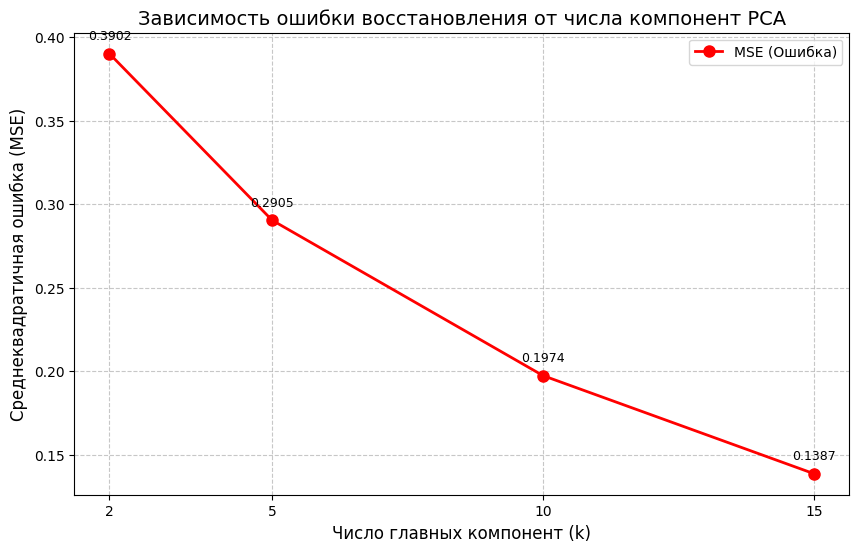

In [84]:
import matplotlib.pyplot as plt

# Настройка стиля графика
plt.figure(figsize=(10, 6))

# Построение линии с точками
plt.plot(k_values, mse_results, 'r-o', linewidth=2, markersize=8, label='MSE (Ошибка)')

# Добавляем подписи к точкам для наглядности
for i, txt in enumerate(mse_results):
    plt.annotate(f"{txt:.4f}", (k_values[i], mse_results[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Оформление осей и заголовка
plt.title('Зависимость ошибки восстановления от числа компонент PCA', fontsize=14)
plt.xlabel('Число главных компонент (k)', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.xticks(k_values) # Чтобы на оси X были только наши k: 2, 5, 10, 15
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

Ошибка монотонно убывает при увеличении числа компонент k. Чем больше осей мы используем для описания данных, тем точнее наше приближение к оригиналу. При k=2 ошибка максимальна, так как мы пытаемся описать 86-мерную структуру всего двумя числами.
Участок  с k=2 до k=5 - самый резкий спад ошибки. Это означает, что первые несколько компонент содержат в себе самую важную информацию о структуре данных (например, различие между движением и покоем).Участок  с k=10 до k=15 - наклон линии становится более пологим. Ошибка продолжает уменьшаться, но уже не так стремительно.

Разница между значениями 10 и 15 невелика, значит точка k=10 является достаточной.После этой точки добавление новых компонент лишь незначительно уточняет мелкие детали, которые часто могут быть просто шумом в данных.Это свидетельствует о высокой избыточности исходных признаков: мы можем сократить размерность данных в 8 раз (с 86 до 10), сохраняя при этом приемлемый уровень ошибки восстановления. Дальнейшее увеличение числа компонент приводит к незначительному выигрышу в точности, что делает k=10 оптимальным выбором для данного датасета.

6.5 Интерпретация результатов

1. Почему при малом числе компонент ошибка восстановления большая?
Метод главных компонент (PCA) работает путем отсечения тех направлений в данных, вдоль которых наблюдается наименьшая изменчивость (дисперсия). Когда мы выбираем очень мало компонентов ,например, k=2 при исходных 86, мы фактически игнорируем 84 измерения данных. В этих отброшенных измерениях содержатся важные детали и индивидуальные особенности объектов. Без них обратное преобразование может восстановить только самый общий скелет данных, теряя точность в конкретных значениях.
2. Почему увеличение числа компонент уменьшает ошибку?
Каждая последующая главная компонента (PC) добавляет в модель новую порцию информации, которую не смогли описать предыдущие компоненты. Чем больше k, тем больше геометрических осей из исходного пространства учитываем. Каждая новая ось уточняет положение объекта в пространстве. Восстановленная точка на графике все ближе перемещается к своему истинному положению в 86-мерном пространстве. Следовательно, разница между оригиналом и реконструкцией (MSE) сокращается.
3. Можно ли полностью восстановить исходные данные при использовании всех компонент?
Да, если число компонентов k равно числу исходных признаков (86), то PCA просто выполняет вращение осей координат, не отбрасывая ни одного измерения. Информационных потерь нет, и при обратном преобразовании (inverse_transform) получим в точности те же числа, что были в исходной стандартизированной матрице. Ошибка MSЕ будет равна нулю.
4. Как это связано с объяснённой дисперсией PCA?
Сумма доли объясненной дисперсии и относительной ошибки восстановления всегда равна 1 (или 100%).
Если 10 компонент объясняют 92% дисперсии, это означает, что оставшиеся 8% информации были потеряны. Именно эти потерянные 8% и создают ошибку MSE.
Чем выше накопленная объясненная дисперсия, тем ниже ошибка восстановления.
5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?
Можно выполнить визуальный анализ зависимости ошибки восстановления и числа компонент,найти точку перегиба, где график из крутого падения переходит в пологий.После этой точки добавление новых компонент почти не улучшает результат — они начинают описывать случайный шум, а не структуру.

Задание 7. Итоговый анализ

1. Какую роль играет снижение размерности в анализе данных?
Снижение размерности:
Борется с «проклятием размерности», уменьшение числа признаков.
Методы вроде PCA оставляют только главные компоненты с большой дисперсией, отбрасывая мелкие отклонения, которые часто являются случайным шумом.
2. Всегда ли уменьшение размерности полезно?
Нет, не всегда.
Происходит потеря информации. Восстановленные данные не идентичны оригиналу. Если слишком сильно снизить размерность, потеряются уникальные признаки, которые важны для решения задачи.
Нелинейные методы (t-SNE) могут создавать ложные кластеры там, где их нет, или изменять расстояния между группами объектов.
3. В каких случаях линейные методы могут работать хуже нелинейных?
Линейные методы (PCA) предполагают, что данные лежат на плоских плоскостях. Они работают хуже, когда:
Данные имеют сложную изогнутую структуру: Например, данные в форме сферы. PCA просто «сплющит» их, потеряв всю топологию, в то время как UMAP или t-SNE смогут развернуть в плоскость.
Важны локальные связи: PCA стремится сохранить глобальную структуру (максимальный разброс). Если  важно, чтобы именно ближайшие соседи остались соседями, нелинейные методы справятся лучше.
4. Преимущества и ограничения PCA, t-SNE и UMAP.
РСА:
Преимущества:Очень быстрый; детерминированный (результат всегда одинаков); позволяет восстанавливать данные обратно.
Ограничения: Только линейные зависимости; плохо подходит для сложной визуализации перепутанных классов.
t-SNE:
Преимущества:Отлично визуализирует локальные кластеры; располагает группы данных так, что их легко отличить глазом.
Ограничения: Очень медленный; результат зависит от случайности; нельзя восстановить исходные данные(После того как он закончил работу, он забывает, как именно он пришел к такому результату); искажает глобальные расстояния.
UMAP:
Преимущества: Быстрее, чем t-SNE; сохраняет и локальную, и глобальную структуру; лучше масштабируется на большие данные.
Ограничения: Требует тонкой настройки параметров (n_neighbors).

Для задач визуализации линейный метод PCA оказался менее эффективным, чем нелинейные t-SNE и UMAP, которые смогли четко разделить похожие активности (например, «ходьба» и «ходьба вверх по лестнице») в разные кластеры. Таким образом, выбор метода зависит от цели: PCA идеален для предобработки и сжатия, а UMAP/t-SNE — для глубокого исследовательского анализа структуры данных.